# 01 Factor Models: CAPM → FF3 → FF5

**Goal.** Take a set of standard test portfolios and explain their returns with three
nested asset-pricing models, adding factors as we go:

1. **CAPM** — one factor: the market (`Mkt-RF`)
2. **Fama-French 3** — adds size (`SMB`) and value (`HML`)
3. **Fama-French 5** — adds profitability (`RMW`) and investment (`CMA`)

**The thing to watch.** Each model produces an *alpha* (intercept) per portfolio —
the average return the factors *fail* to explain. If the added factors are real
sources of priced risk, the alphas should **shrink toward zero** as we move
CAPM → FF3 → FF5. 


In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))   # so we can import from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import get_french      # downloads a Ken French dataset and caches it locally as parquet

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.figsize"] = (10, 5)

/Users/Parimah/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/Parimah/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load the data

We need **Factors** and **Test Portfolios**:

1. **Factors** — we pull the **5-factor** file `F-F_Research_Data_5_Factors_2x3`,
   which contains `Mkt-RF, SMB, HML, RMW, CMA, RF` in one place. Pulling one file keeps
   the risk-free rate `RF` consistent across all three models.

   > ⚠️ *Caveat:* the `SMB` in the 5-factor file is built slightly differently from
   > the `SMB` in the original 3-factor file (it averages across more sorts).

2. **Test portfolios** — the classic `25_Portfolios_5x5`: 25 portfolios formed on
   a 5×5 sort of **size** × **book-to-market**. These are the canonical left-hand-side
   assets for testing Fama-French models.


All French returns are **in percent per month**.

In [2]:
# Monthly sample. French data starts 1963-07 for these series.
START, END = "1963-07", "2024-12"

factors = get_french("F-F_Research_Data_5_Factors_2x3", start=START, end=END)
portfolios = get_french("25_Portfolios_5x5", start=START, end=END)

print("factors:   ", factors.shape, "->", list(factors.columns))
print("portfolios:", portfolios.shape)

factors:    (738, 6) -> ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
portfolios: (738, 25)


### Inspect the factors

What each column means (all are monthly returns, in %):

| Factor | Name | What it captures | Long − short |
|---|---|---|---|
| `Mkt-RF` | Market | Excess return of the whole market over the risk-free rate | Market − T-bill |
| `SMB` | Size | Small-cap stocks tend to beat large-cap | Small − Big |
| `HML` | Value | Cheap (high book/price) beats expensive (growth) | High − Low B/M |
| `RMW` | Profitability | Profitable firms beat unprofitable ones | Robust − Weak |
| `CMA` | Investment | Conservative (low-investment) firms beat aggressive ones | Conservative − Aggressive |
| `RF` | Risk-free | The risk-free rate (T-bill); not a factor — used to form excess returns | — |

In [3]:
factors.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-31 23:59:59.999999,-0.3900,-0.4800,-0.8100,0.6400,-1.1500,0.2700
1963-08-31 23:59:59.999999,5.0800,-0.8000,1.7000,0.4000,-0.3800,0.2500
1963-09-30 23:59:59.999999,-1.5700,-0.4300,0.0000,-0.7800,0.1500,0.2700
1963-10-31 23:59:59.999999,2.5400,-1.3400,-0.0400,2.7900,-2.2500,0.2900
1963-11-30 23:59:59.999999,-0.8600,-0.8500,1.7300,-0.4300,2.2700,0.2700


In [4]:
factors.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Mkt-RF,0.5867,4.4760,-23.1900,16.1000
SMB,0.1930,3.0361,-15.5400,18.4600
HML,0.2819,2.9714,-13.8300,12.8600
RMW,0.2810,2.2172,-18.9500,13.0500
CMA,0.2509,2.0574,-7.0800,9.0100
RF,0.3637,0.2636,0.0000,1.3500


### Inspect the test portfolios

Columns are labeled `SIZE B/M`, e.g. `SMALL LoBM` (small-cap, low book-to-market /
growth) through `BIG HiBM` (large-cap, high book-to-market / value).

The 25 columns come in a fixed **row-major order**: outer loop is **size** (ME1→ME5,
small→big), inner loop is **book-to-market** (BM1→BM5, growth→value). Laid out as the
5×5 grid:

| Size \\ B/M | BM1 (Growth) | BM2 | BM3 | BM4 | BM5 (Value) |
|---|---|---|---|---|---|
| **ME1 (Small)** | `SMALL LoBM` | `ME1 BM2` | `ME1 BM3` | `ME1 BM4` | `SMALL HiBM` |
| **ME2** | `ME2 BM1` | `ME2 BM2` | `ME2 BM3` | `ME2 BM4` | `ME2 BM5` |
| **ME3** | `ME3 BM1` | `ME3 BM2` | `ME3 BM3` | `ME3 BM4` | `ME3 BM5` |
| **ME4** | `ME4 BM1` | `ME4 BM2` | `ME4 BM3` | `ME4 BM4` | `ME4 BM5` |
| **ME5 (Big)** | `BIG LoBM` | `ME5 BM2` | `ME5 BM3` | `ME5 BM4` | `BIG HiBM` |


In [30]:
portfolios.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
1963-07-31 23:59:59.999999,1.1287,-0.3632,0.7223,-0.0413,-1.2447,-1.8076,0.1929,-1.0149,-1.9749,-1.1880,...,-0.9115,-1.7733,-1.9168,-1.5745,-1.8574,0.1391,0.4839,1.1360,-0.4285,-1.1045
1963-08-31 23:59:59.999999,4.2396,1.3730,1.4917,2.5068,4.6644,5.5703,4.5220,4.4450,4.4662,8.2451,...,5.5754,4.7469,6.2516,7.6941,5.3456,5.7823,4.2633,4.6341,8.1704,6.3984
1963-09-30 23:59:59.999999,-1.7343,0.6204,-1.0007,-1.5215,-0.3584,-4.0525,-1.5072,-0.8638,-1.4935,-2.9243,...,-2.6644,-2.1463,-1.7882,-3.9641,-2.0002,-1.3752,-0.8081,-0.8497,-0.1912,-3.5033
1963-10-31 23:59:59.999999,0.3778,-0.7329,1.3066,0.1904,2.3711,1.1926,4.2411,2.3526,2.3058,3.9314,...,-0.2415,0.6990,2.5214,4.8524,0.6138,5.3261,1.7420,-0.3354,2.4176,0.4702
1963-11-30 23:59:59.999999,-3.3319,-3.8436,-1.7893,-1.0535,-1.1077,-4.2596,-1.7484,-0.7845,-0.0554,-0.1150,...,-0.9083,-0.6311,-0.7516,1.3596,3.5407,-1.2669,1.0080,-1.6914,-2.1316,1.3496


### Sanity checks

In [6]:
# 1) Indexes align on the same monthly dates
assert factors.index.equals(portfolios.index), "date indexes do not match!"

# 2) No missing values (French uses -99.99 for missing; flag if present)
print("factors  has -99.99 sentinels:", (factors == -99.99).any().any())
print("ports    has -99.99 sentinels:", (portfolios == -99.99).any().any())
print("factors  NaNs:", int(factors.isna().sum().sum()))
print("ports    NaNs:", int(portfolios.isna().sum().sum()))

# 3) Date range
print("range:", factors.index.min().date(), "->", factors.index.max().date(),
      f"({len(factors)} months)")

factors  has -99.99 sentinels: False
ports    has -99.99 sentinels: False
factors  NaNs: 0
ports    NaNs: 0
range: 1963-07-31 -> 2024-12-31 (738 months)


## Excess returns & factor sets

**Excess returns for the test portfolios.** Asset-pricing regressions explain
*excess* returns — return above the risk-free rate. So we subtract `RF` from each of
the 25 portfolios:
$$R^{e}_{i,t} = R_{i,t} - R_{f,t}$$
We do **not** subtract `RF` from the factors: `Mkt-RF` is already an excess return, and
`SMB, HML, RMW, CMA` are zero-cost long-short spreads, so there's no risk-free leg to net out.

In [31]:
# (a) Excess returns: subtract RF from every portfolio column
rf = factors["RF"]
excess = portfolios.sub(rf, axis=0)

In [8]:
# Sanity: raw vs excess means for a few portfolios (RF > 0, so excess mean < raw mean)
check = pd.DataFrame({
    "raw_mean":    portfolios.mean(),
    "excess_mean": excess.mean(),
    "diff(=mean RF)": portfolios.mean() - excess.mean(),
}).head()
print(f"mean RF over sample = {rf.mean():.4f}% / month")
check

mean RF over sample = 0.3637% / month


,raw_mean,excess_mean,diff(=mean RF)
SMALL LoBM,0.6532,0.2895,0.3637
ME1 BM2,1.1206,0.7568,0.3637
ME1 BM3,1.1277,0.7639,0.3637
ME1 BM4,1.3130,0.9492,0.3637
SMALL HiBM,1.4614,1.0976,0.3637


In [9]:
# (b) Define the three nested model specifications
MODELS = {
    "CAPM": ["Mkt-RF"],
    "FF3":  ["Mkt-RF", "SMB", "HML"],
    "FF5":  ["Mkt-RF", "SMB", "HML", "RMW", "CMA"],
}

# Confirm every factor we reference actually exists in the factors table
for name, cols in MODELS.items():
    missing = [c for c in cols if c not in factors.columns]
    assert not missing, f"{name}: missing {missing}"
    print(f"{name:5s}: {cols}")

CAPM : ['Mkt-RF']
FF3  : ['Mkt-RF', 'SMB', 'HML']
FF5  : ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']


In [ ]:
## reusable functions

import statsmodels.api as sm

def run_model(excess_df, factors_df, factor_cols):
    """OLS time-series regression of each portfolio's excess return on `factor_cols`.

    Returns a DataFrame (one row per portfolio) with alpha, t(alpha), R², and betas.
    """
    rows = {}
    X = sm.add_constant(factors_df[factor_cols])      # design matrix shared across portfolios
    for col in excess_df.columns:
        res = sm.OLS(excess_df[col], X).fit()
        rows[col] = {
            "alpha":   res.params["const"],
            "t_alpha": res.tvalues["const"],
            "R2":      res.rsquared,
            **{f"b_{f}": res.params[f] for f in factor_cols},
        }
    return pd.DataFrame(rows).T

def to_grid(series):
    """Reshape a 25-vector (row-major size×B/M) into the labeled 5×5 grid."""
    return pd.DataFrame(
        series.values.reshape(5, 5).astype(float),
        index=["ME1 (Small)", "ME2", "ME3", "ME4", "ME5 (Big)"],
        columns=["BM1 (Growth)", "BM2", "BM3", "BM4", "BM5 (Value)"],
    )

def summarize(name):
    r = RESULTS[name]
    n_sig = int((r["t_alpha"].abs() > 1.96).sum())
    return {
        "model": name,
        "mean |alpha|": r["alpha"].abs().mean(),
        "max |alpha|":  r["alpha"].abs().max(),
        "# |t|>1.96 (of 25)": n_sig,
        "mean R2": r["R2"].mean(),
    }

RESULTS = {}   # model name -> per-portfolio DataFrame
ALPHAS  = {}   # model name -> alpha Series (for the Step 6 comparison)

## CAPM — the baseline

The CAPM says one factor — the market — explains everything, so for each portfolio $i$:
$$R^{e}_{i,t} = \alpha_i + \beta_i\,(\text{Mkt-RF})_t + \varepsilon_{i,t}$$

We run this time-series regression for **each of the 25 portfolios** and read off:

- **$\alpha_i$** — average monthly return the market *fails* to explain. CAPM's claim is $\alpha_i = 0$ for all $i$.
- **$t(\alpha_i)$** — is that alpha statistically distinguishable from zero? $|t| > 1.96$ ≈ significant at 5%.
- **$\beta_i$** — market exposure; **$R^2$** — how much of the variance the market explains.


In [32]:
RESULTS["CAPM"] = run_model(excess, factors, MODELS["CAPM"])
ALPHAS["CAPM"]  = RESULTS["CAPM"]["alpha"]

print("Alpha grid:")
display(to_grid(ALPHAS["CAPM"]).round(3))

pd.DataFrame([summarize("CAPM")]).set_index("model").round(4)

Alpha grid:


,BM1 (Growth),BM2,BM3,BM4,BM5 (Value)
ME1 (Small),-0.5370,0.0400,0.1110,0.3390,0.4700
ME2,-0.2760,0.0860,0.2210,0.2890,0.3150
ME3,-0.2340,0.1280,0.1570,0.2770,0.3420
ME4,-0.0530,0.0180,0.1240,0.2730,0.2170
ME5 (Big),0.0280,0.0220,0.0640,0.0140,0.1120


,mean |alpha|,max |alpha|,# |t|>1.96 (of 25),mean R2
model,,,,
CAPM,0.1899,0.5371,11,0.7388


## Fama-French 3 — add size & value

Same regression, three factors now:
$$R^{e}_{i,t} = \alpha_i + \beta^{mkt}_i\,\text{Mkt-RF} + \beta^{smb}_i\,\text{SMB} + \beta^{hml}_i\,\text{HML} + \varepsilon_{i,t}$$

If `SMB`/`HML` are the missing priced risks, the structured CAPM alphas (the value gradient,
the small-growth corner) should largely collapse.

In [20]:
RESULTS["FF3"] = run_model(excess, factors, MODELS["FF3"])
ALPHAS["FF3"]  = RESULTS["FF3"]["alpha"]

print("Alpha grid (% / month):")
display(to_grid(ALPHAS["FF3"]).round(3))
pd.DataFrame([summarize("CAPM"), summarize("FF3")]).set_index("model").round(4)

Alpha grid (% / month):


,BM1 (Growth),BM2,BM3,BM4,BM5 (Value)
ME1 (Small),-0.4800,0.0020,-0.0230,0.1390,0.1920
ME2,-0.1780,0.0240,0.0660,0.0660,0.0050
ME3,-0.1170,0.0610,-0.0050,0.0430,0.0200
ME4,0.0700,-0.0550,-0.0370,0.0620,-0.0940
ME5 (Big),0.1620,-0.0030,-0.0380,-0.2200,-0.1870


,mean |alpha|,max |alpha|,# |t|>1.96 (of 25),mean R2
model,,,,
CAPM,0.1899,0.5371,11,0.7388
FF3,0.0939,0.4796,8,0.9149


## Fama-French 5 — add profitability & investment

Two more factors, `RMW` (profitability) and `CMA` (investment):
$$R^{e}_{i,t} = \alpha_i + \beta^{mkt}_i\text{Mkt-RF} + \beta^{smb}_i\text{SMB} + \beta^{hml}_i\text{HML} + \beta^{rmw}_i\text{RMW} + \beta^{cma}_i\text{CMA} + \varepsilon_{i,t}$$

In [21]:
RESULTS["FF5"] = run_model(excess, factors, MODELS["FF5"])
ALPHAS["FF5"]  = RESULTS["FF5"]["alpha"]

print("Alpha grid (% / month):")
display(to_grid(ALPHAS["FF5"]).round(3))
pd.DataFrame([summarize(m) for m in ["CAPM", "FF3", "FF5"]]).set_index("model").round(4)

Alpha grid (% / month):


,BM1 (Growth),BM2,BM3,BM4,BM5 (Value)
ME1 (Small),-0.2820,0.1420,0.0020,0.1530,0.1450
ME2,-0.0810,0.0160,0.0000,0.0290,-0.0110
ME3,-0.0240,0.0110,-0.0770,-0.0080,-0.0360
ME4,0.1360,-0.1450,-0.1280,0.0410,-0.0830
ME5 (Big),0.1150,-0.0920,-0.0810,-0.2210,-0.0320


,mean |alpha|,max |alpha|,# |t|>1.96 (of 25),mean R2
model,,,,
CAPM,0.1899,0.5371,11,0.7388
FF3,0.0939,0.4796,8,0.9149
FF5,0.0835,0.2822,8,0.9195


## Do the alphas shrink? — the comparison

,mean |alpha|,max |alpha|,# |t|>1.96 (of 25),mean R2
model,,,,
CAPM,0.1899,0.5371,11,0.7388
FF3,0.0939,0.4796,8,0.9149
FF5,0.0835,0.2822,8,0.9195


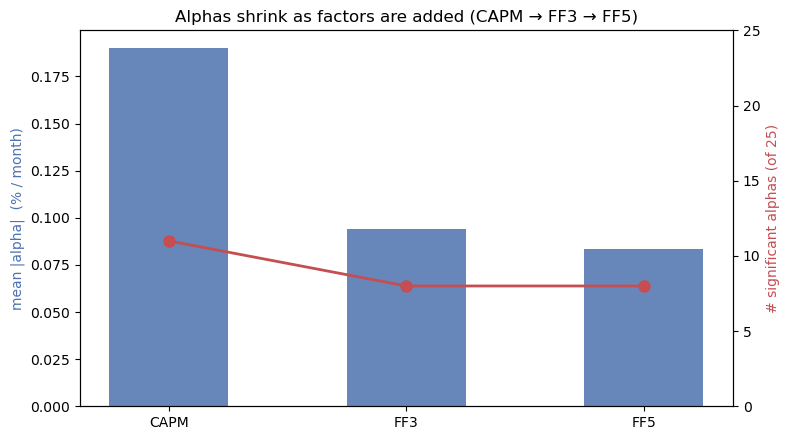

In [22]:
summary = pd.DataFrame([summarize(m) for m in ["CAPM", "FF3", "FF5"]]).set_index("model")
display(summary.round(4))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = range(3); models = ["CAPM", "FF3", "FF5"]
ax1.bar(x, summary["mean |alpha|"], color="#4C72B0", alpha=0.85, width=0.5)
ax1.set_ylabel("mean |alpha|  (% / month)", color="#4C72B0")
ax1.set_xticks(list(x)); ax1.set_xticklabels(models)
ax2 = ax1.twinx()
ax2.plot(x, summary["# |t|>1.96 (of 25)"], "o-", color="#C44E52", lw=2, ms=8)
ax2.set_ylabel("# significant alphas (of 25)", color="#C44E52")
ax2.set_ylim(0, 25)
ax1.set_title("Alphas shrink as factors are added (CAPM → FF3 → FF5)")
plt.tight_layout()

### Alpha heatmap

Use the buttons to switch model. Color is on a **shared, zero-centered scale** across all
three models, so cells genuinely fade toward white as alphas die. Each cell shows the
alpha in %/month with significance stars:

- `*`  = |t| > 1.96  (significant at 5%)
- `**` = |t| > 2.58  (significant at 1%)

In [23]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected+plotly_mimetype"  # render in VSCode & exported HTML

MODEL_ORDER = ["CAPM", "FF3", "FF5"]
xlab = ["Growth", "BM2", "BM3", "BM4", "Value"]
ylab = ["Small", "ME2", "ME3", "ME4", "Big"]
zabs = max(ALPHAS[m].abs().max() for m in MODEL_ORDER)   # shared color limit

def _stars(t):
    a = abs(t)
    return "**" if a > 2.58 else ("*" if a > 1.96 else "")

traces = []
for i, m in enumerate(MODEL_ORDER):
    a = ALPHAS[m].values.reshape(5, 5).astype(float)
    t = RESULTS[m]["t_alpha"].values.reshape(5, 5).astype(float)
    txt = [[f"{a[r,c]:.2f}{_stars(t[r,c])}" for c in range(5)] for r in range(5)]
    traces.append(go.Heatmap(
        z=a, x=xlab, y=ylab, text=txt, texttemplate="%{text}",
        zmid=0, zmin=-zabs, zmax=zabs, colorscale="RdBu", reversescale=True,
        visible=(i == 0), colorbar=dict(title="alpha<br>%/mo"),
        hovertemplate="size=%{y} · B/M=%{x}<br>alpha=%{z:.3f} %/mo<extra></extra>"))

title = "{m}: monthly alphas (% / month)   ·   * |t|>1.96   ** |t|>2.58"
buttons = [dict(label=m, method="update",
                args=[{"visible": [j == i for j in range(len(MODEL_ORDER))]},
                      {"title": title.format(m=m)}])
           for i, m in enumerate(MODEL_ORDER)]

fig = go.Figure(data=traces)
fig.update_layout(
    title=title.format(m="CAPM"),
    updatemenus=[dict(type="buttons", direction="right", showactive=True,
                      x=0.5, xanchor="center", y=-0.12, yanchor="top", buttons=buttons)],
    yaxis=dict(autorange="reversed"), width=620, height=560,
    margin=dict(t=70, b=90))
fig.show()

### Takeaway

Reading the trend chart and clicking CAPM → FF3 → FF5:

- The pattern in CAPM is structured, not random: small-cap and high-B/M (value) corners tend to
  carry the biggest positive alphas. That structure is precisely what `SMB` and `HML` are
  built to absorb.
- **mean |alpha| falls** as we add factors and the **count of significant alphas drops** at each step — the
  central result. Returns that looked like market-unexplained "alpha" were mostly exposure
  to size, value, profitability, and investment.
- The biggest cleanup happens at **FF3** (size+value absorb the value gradient and the
  small-growth corner). **FF5** mops up additional structure via profitability/investment.
- Whatever significant alpha *survives* FF5 is the interesting residual — either genuine
  mispricing, or exposure to a factor this model still omits (e.g. **momentum**, which FF5
  doesn't include). 
  
This is the practical lesson from earlier made concrete: before paying for "alpha," check
whether cheap factor exposure already explains it.